# aihydro-watershed — Comprehensive Demo

End-to-end walkthrough of all five capability domains:

| # | Domain | Key function |
|---|--------|--------------|
| 1 | **Delineation** (USGS gauge) | `delineate_watershed(gauge_id)` |
| 2 | **Delineation** (global pour point) | `delineate_from_point(lat, lon)` |
| 3 | **Geomorphic characterization** | `extract_geomorphic_parameters(gdf, dem)` |
| 4 | **Terrain / Curve Number** | `create_curve_number_grid_from_geometry(geom)` |
| 5 | **Hydrological signatures** | `extract_hydrological_signatures(gauge_id, geojson, area)` |

**Demo watershed**: USGS 01589000 — Patuxent River at Laurel, MD (~900 km²)

```bash
pip install aihydro-watershed
```

In [11]:
import warnings
import logging
warnings.filterwarnings('ignore')
# Suppress router-level fallback warnings so notebook output stays clean.
# (GEE → local_merit tier-switching is expected behaviour, not an error.)
logging.getLogger('aihydro_watershed').setLevel(logging.ERROR)

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from shapely.geometry import shape

import aihydro_watershed
print(f'aihydro-watershed {aihydro_watershed.__version__}')
%matplotlib inline


aihydro-watershed 0.1.0


---
## 1. Delineation from a USGS gauge (CONUS)

`delineate_watershed(gauge_id)` queries the NLDI + NWIS APIs and returns the full watershed polygon, area, and station metadata as a typed `HydroResult`.

In [2]:
from aihydro_watershed.characterize.watershed import delineate_watershed

GAUGE_ID = '01589000'   # Patuxent River at Laurel, MD

result = delineate_watershed(GAUGE_ID)

print(f"Gauge  : {result.data['gauge_name']}")
print(f"Area   : {result.data['area_km2']:.1f} km²")
print(f"Outlet : {result.data['gauge_lat']:.4f}°N, {result.data['gauge_lon']:.4f}°E")
print(f"HUC-02 : {result.data['huc_02']}")
print(f"Source : {result.meta.sources[0].name}")

Gauge  : Patapsco River At Hollofield, MD
Area   : 741.4 km²
Outlet : 39.3103°N, -76.7924°E
HUC-02 : 02
Source : USGS NLDI


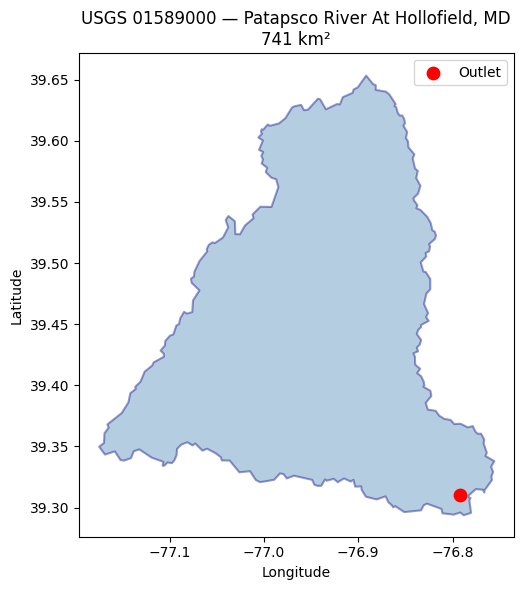

In [3]:
# Convert GeoJSON → GeoDataFrame for plotting
geojson   = result.data['geometry_geojson']
area_km2  = result.data['area_km2']
outlet_lat = result.data['gauge_lat']
outlet_lon = result.data['gauge_lon']

ws_gdf = gpd.GeoDataFrame(
    {'name': [result.data['gauge_name']]},
    geometry=[shape(geojson)],
    crs='EPSG:4326'
)

fig, ax = plt.subplots(figsize=(7, 6))
ws_gdf.plot(ax=ax, facecolor='steelblue', edgecolor='navy', alpha=0.4, linewidth=1.5)
ax.scatter([outlet_lon], [outlet_lat], color='red', zorder=5, s=80, label='Outlet')
ax.set_title(f"USGS {GAUGE_ID} — {result.data['gauge_name']}\n{area_km2:.0f} km²", fontsize=12)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.legend()
plt.tight_layout()
plt.show()

---
## 2. Delineation from a global pour point

`delineate_from_point(lat, lon)` works anywhere on Earth. For CONUS coordinates it routes via NLDI; outside CONUS it uses MERIT-Hydro/pyflwdir (GEE tier, reliable for basins < ~8 000 km²). Larger basins fall back through local MERIT raster and MERIT-Basins hybrid tiers — stage regional data first with `merit_ensure_routing_region()`.

Second example: **Thur River at Andelfingen, Switzerland** (~1 750 km²).

In [4]:
from aihydro_watershed.delineation.router import delineate_from_point

# ── CONUS: use the exact NLDI gauge outlet (avoids COMID area mismatch) ──────
# Coordinates come from result.data['gauge_lat/lon'] in cell 3 above.
r_conus = delineate_from_point(
    lat=outlet_lat, lon=outlet_lon,
    expected_area_km2=area_km2,   # NLDI-reported area → guaranteed match
    method='auto',
)
print(f"CONUS  | method={r_conus.data['method_used']!r:25s} | area={r_conus.data['area_km2']:.1f} km²")

# ── Global: Thur River at Andelfingen, Switzerland (~1 750 km²) ──────────────
# auto-tier order: GEE → local MERIT → MERIT-Basins hybrid → raw DEM.
# For this basin GEE may fall through to local_merit_pyflwdir (silent, expected).
r_global = None
try:
    r_global = delineate_from_point(
        lat=47.59, lon=8.68,
        expected_area_km2=1_750,
        method='auto',
    )
    g_flags = r_global.data.get('quality_flags', [])
    print(f"Global | method={r_global.data['method_used']!r:25s} | area={r_global.data['area_km2']:.1f} km²")
    if g_flags:
        print(f"         quality_flags: {g_flags}")
except Exception as e:
    print(f"Global | delineation unavailable: {e}")
    print("         → stage local MERIT data: merit_ensure_routing_region(47.59, 8.68)")

CONUS  | method='nldi_comid'              | area=741.4 km²
Global | method='local_merit_pyflwdir'    | area=1722.0 km²
         quality_flags: ['ADAPTIVE_WINDOW_EXPANDED']


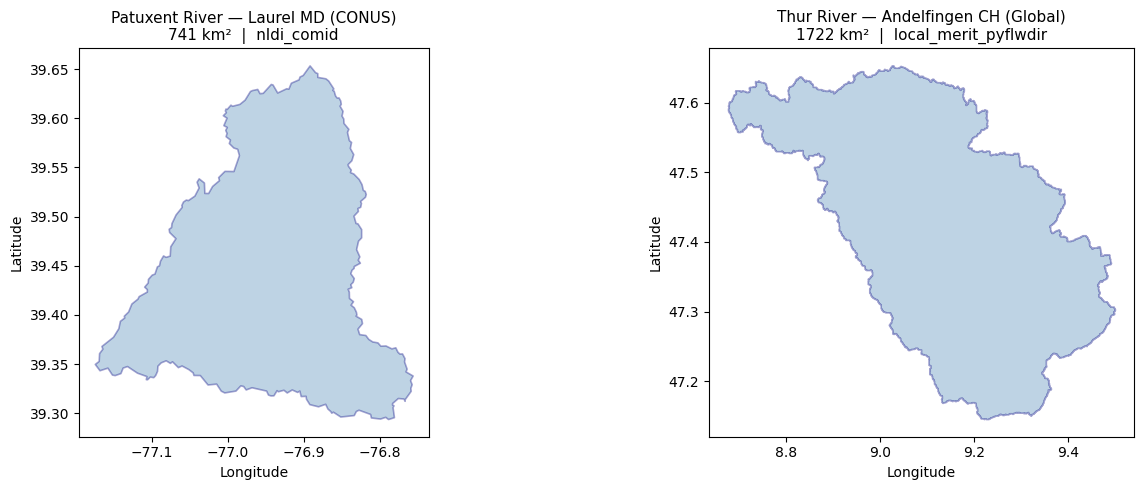

In [5]:
# Plot both watersheds (global panel only shown when delineation succeeded)
results_to_plot = [(r_conus, 'Patuxent River — Laurel MD (CONUS)')]
if r_global is not None:
    results_to_plot.append((r_global, 'Thur River — Andelfingen CH (Global)'))

fig, axes = plt.subplots(1, len(results_to_plot), figsize=(7 * len(results_to_plot), 5))
if len(results_to_plot) == 1:
    axes = [axes]

for ax, (r, title) in zip(axes, results_to_plot):
    gdf = gpd.GeoDataFrame(geometry=[shape(r.data['geometry_geojson'])], crs='EPSG:4326')
    gdf.plot(ax=ax, facecolor='steelblue', edgecolor='navy', alpha=0.35, linewidth=1.2)
    method_label = r.data.get('method_used', '?')
    ax.set_title(f"{title}\n{r.data['area_km2']:.0f} km²  |  {method_label}", fontsize=11)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

plt.tight_layout()
plt.show()

---
## 3. Geomorphic characterization

`extract_geomorphic_parameters()` computes 20+ CAMELS-compatible geomorphic attributes — shape indices, relief, drainage density, elongation ratio, etc. — from the watershed polygon and DEM.

The companion `get_geomorphic_summary()` returns a compact dict suitable for a CAMELS attribute table.

In [ ]:
from aihydro_watershed.characterize.geomorphic import (
    extract_geomorphic_parameters,
    get_geomorphic_summary,
)

# ── CONUS watershed (Patapsco River, MD) ─────────────────────────────────────
print("=== CONUS watershed ===")
params, units = extract_geomorphic_parameters(ws_gdf, outlet_lat, outlet_lon)
summary = params   # alias so downstream cells can use 'summary'
print(get_geomorphic_summary(ws_gdf, outlet_lat, outlet_lon))

df_conus = pd.Series(
    {k: v for k, v in params.items() if isinstance(v, float)},
    name=f'CONUS ({result.data["gauge_name"][:20]})'
).round(3)

# ── Global watershed (Thur River, Switzerland) ───────────────────────────────
# Uses global DEM (GLO-30 / MERIT) and UTM metric CRS — no CONUS-only code.
params_global = None
if r_global is not None:
    print("\n=== Global watershed (Thur River, Switzerland) ===")
    ws_gdf_global = gpd.GeoDataFrame(
        geometry=[shape(r_global.data['geometry_geojson'])], crs='EPSG:4326'
    )
    g_lat = r_global.data['outlet_lat']
    g_lon = r_global.data['outlet_lon']
    params_global, _ = extract_geomorphic_parameters(ws_gdf_global, g_lat, g_lon)
    df_global = pd.Series(
        {k: v for k, v in params_global.items() if isinstance(v, float)},
        name='Global (Thur CH)'
    ).round(3)
    print(get_geomorphic_summary(ws_gdf_global, g_lat, g_lon))

# ── Side-by-side comparison table ───────────────────────────────────────────
# Note: pct_water_wetland / pct_urban / pct_sinks require ESA WorldCover
# integration, planned for Wave C (aihydro-lsh global CAMELS recipes).
# CN_weighted is patched from the explicit SCS-CN step (cell 4 below).
if params_global is not None:
    pd.concat([df_conus, df_global], axis=1)
else:
    df_conus.to_frame('value')

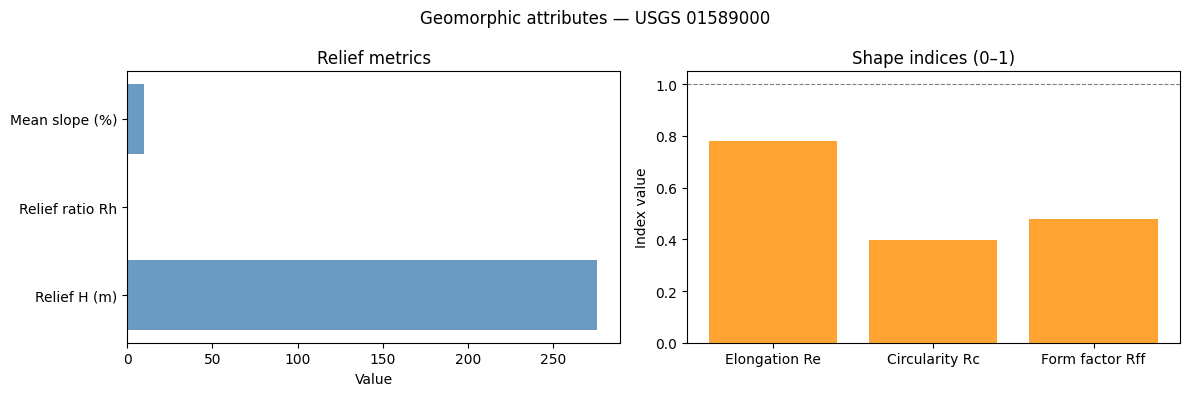

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Relief metrics  (H_m=relief, Rh=relief ratio, Ls_pct=mean slope %)
relief_keys = ['H_m', 'Rh', 'Ls_pct']
relief_labels = ['Relief H (m)', 'Relief ratio Rh', 'Mean slope (%)']
relief_vals = [params.get(k, 0) or 0 for k in relief_keys]
axes[0].barh(relief_labels, relief_vals, color='steelblue', alpha=0.8)
axes[0].set_title('Relief metrics')
axes[0].set_xlabel('Value')

# Shape indices  (Re=elongation, Rc=circularity, Rff=form factor)
shape_keys   = ['Re', 'Rc', 'Rff']
shape_labels = ['Elongation Re', 'Circularity Rc', 'Form factor Rff']
shape_vals   = [params.get(k, 0) or 0 for k in shape_keys]
axes[1].bar(shape_labels, shape_vals, color='darkorange', alpha=0.8)
axes[1].set_title('Shape indices (0–1)')
axes[1].set_ylabel('Index value')
axes[1].axhline(1.0, color='grey', linestyle='--', linewidth=0.8)

plt.suptitle(f'Geomorphic attributes — USGS {GAUGE_ID}', fontsize=12)
plt.tight_layout()
plt.show()

---
## 4. Terrain: Curve Number grid

`create_curve_number_grid_from_geometry()` fetches NLCD land cover + SSURGO soils, joins them to a TR-55 CN lookup table, and returns a 30 m CN raster for the watershed. Used for event-based runoff estimation (SCS-CN method).

In [ ]:
from aihydro_watershed.terrain.curve_number import create_curve_number_grid_from_geometry

cn_result = create_curve_number_grid_from_geometry(
    geometry=ws_gdf,
    year=2019,
    resolution=30,
    save_outputs=False,
    create_visualizations=False,
)

# Key is 'statistics', sub-keys are 'cn_mean', 'cn_median', 'cn_std'
cn_stats = cn_result.get('statistics', {})
print(f"Mean CN  : {cn_stats.get('cn_mean', float('nan')):.1f}")
print(f"Median CN: {cn_stats.get('cn_median', float('nan')):.1f}")
print(f"Std CN   : {cn_stats.get('cn_std', float('nan')):.1f}")

# Patch CN_weighted into geomorphic params (avoids re-running DEM + land cover)
params['CN_weighted'] = cn_stats.get('cn_mean', np.nan)

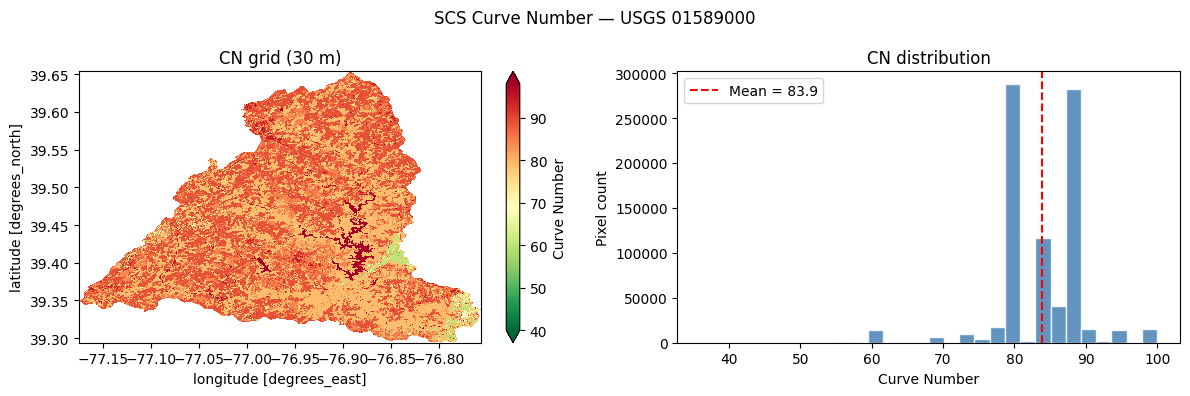

In [17]:
# Plot CN distribution
cn_grid = cn_result.get('cn_grid')

if cn_grid is not None:
    cn_vals = cn_grid.values.ravel()
    cn_vals = cn_vals[np.isfinite(cn_vals) & (cn_vals > 0)]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Spatial map
    cn_grid.plot(ax=axes[0], cmap='RdYlGn_r', vmin=40, vmax=98,
                 cbar_kwargs={'label': 'Curve Number'})
    axes[0].set_title('CN grid (30 m)')

    # Histogram
    axes[1].hist(cn_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[1].axvline(cn_vals.mean(), color='red', linestyle='--', label=f'Mean = {cn_vals.mean():.1f}')
    axes[1].set_xlabel('Curve Number'); axes[1].set_ylabel('Pixel count')
    axes[1].set_title('CN distribution'); axes[1].legend()

    plt.suptitle(f'SCS Curve Number — USGS {GAUGE_ID}', fontsize=12)
    plt.tight_layout()
    plt.show()

In [13]:
# Event runoff estimation (SCS-CN method)
from aihydro_watershed.terrain.event_runoff import scs_cn_runoff

mean_cn = cn_stats.get('cn_mean', 75)   # key is 'cn_mean' not 'mean_cn'
rainfall_depths_mm = [10, 25, 50, 75, 100, 150]

rows = []
for P in rainfall_depths_mm:
    Q = scs_cn_runoff(rainfall_mm=P, cn=mean_cn)
    rows.append({'Rainfall P (mm)': P, 'Runoff Q (mm)': round(Q, 1),
                 'Runoff ratio': round(Q / P, 3) if P > 0 else 0})

pd.DataFrame(rows)

,Rainfall P (mm),Runoff Q (mm),Runoff ratio
0,10,0.0,0.000
1,25,3.6,0.145
2,50,18.2,0.364
3,75,37.4,0.498
4,100,58.6,0.586
5,150,104.1,0.694


---
## 5. Hydrological signatures (CAMELS-style)

`extract_hydrological_signatures()` computes 17 CAMELS-compatible signatures from daily streamflow: baseflow index, flow-duration curve slope, high/low flow frequencies, half-flow date, stream elasticity, and more.

**Streamflow source — automatic routing (no manual selection needed):**
| Input | Backend |
|---|---|
| USGS `gauge_id` | NWIS daily Q — CONUS only |
| `gauge_id=None` | GEOGLOWS v2 (anonymous S3 Zarr, 1940→present) → Open-Meteo GloFAS v4 fallback |
| `q_cms_series` | Pre-loaded array — skips all fetching |


In [14]:
from aihydro_watershed.signatures.signatures import extract_hydrological_signatures

sig_result = extract_hydrological_signatures(
    gauge_id=GAUGE_ID,
    watershed_geojson=geojson,
    area_km2=area_km2,
    start_date='1989-10-01',
    end_date='2009-09-30',
)

sigs = sig_result.data
# Filter to numeric-only values before rounding (data also contains strings/dicts)
pd.Series({k: v for k, v in sigs.items() if isinstance(v, (int, float))}).rename('value').round(4).to_frame()

,value
q_mean,0.5406
q_std,0.8522
q5,1.6357
q95,0.0924
q_median,0.3300
baseflow_index,0.6283
high_q_freq,5.4951
high_q_dur,1.6786
low_q_freq,23.5004
low_q_dur,9.5714


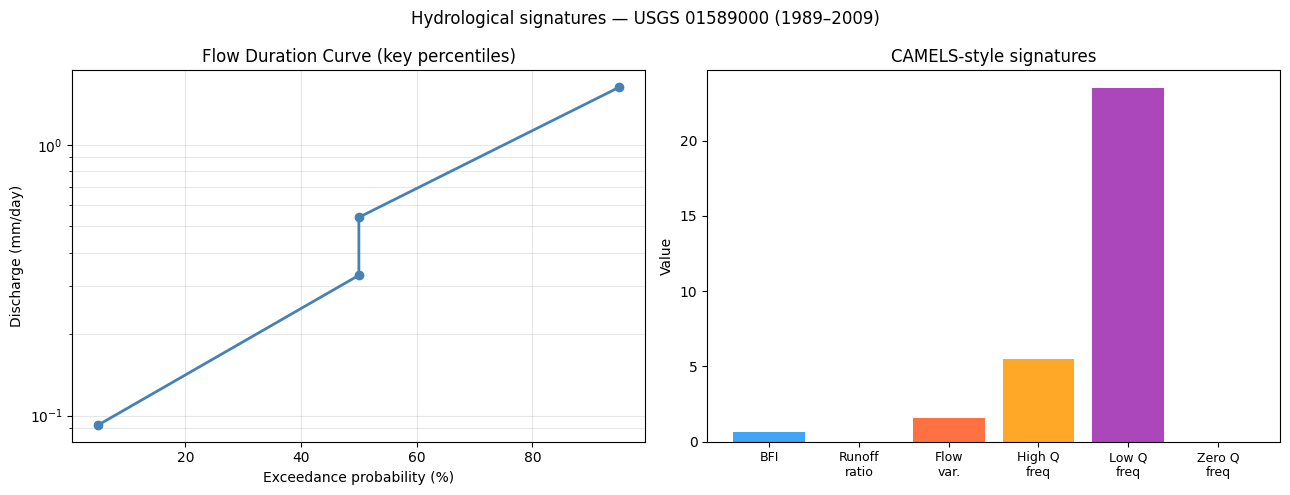

In [15]:
# Flow Duration Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# FDC (from stored percentiles q5/q95/q_median)
q_vals = [sigs.get('q95', np.nan), sigs.get('q_median', np.nan),
          sigs.get('q_mean', np.nan), sigs.get('q5', np.nan)]
exc_probs = [5, 50, 50, 95]
axes[0].semilogy([5, 50, 50, 95], q_vals, 'o-', color='steelblue', linewidth=2)
axes[0].set_xlabel('Exceedance probability (%)')
axes[0].set_ylabel('Discharge (mm/day)')
axes[0].set_title('Flow Duration Curve (key percentiles)')
axes[0].grid(True, which='both', alpha=0.3)

# Signature bar chart — coerce None → np.nan so matplotlib doesn't crash
sig_keys = ['baseflow_index', 'runoff_ratio', 'flow_variability',
            'high_q_freq', 'low_q_freq', 'zero_q_freq']
sig_vals = [v if v is not None else np.nan for v in (sigs.get(k) for k in sig_keys)]
colors = ['#2196F3', '#4CAF50', '#FF5722', '#FF9800', '#9C27B0', '#607D8B']
bars = axes[1].bar(range(len(sig_keys)), sig_vals, color=colors, alpha=0.85)
axes[1].set_xticks(range(len(sig_keys)))
axes[1].set_xticklabels(
    ['BFI', 'Runoff\nratio', 'Flow\nvar.', 'High Q\nfreq', 'Low Q\nfreq', 'Zero Q\nfreq'],
    fontsize=9
)
axes[1].set_title('CAMELS-style signatures')
axes[1].set_ylabel('Value')

plt.suptitle(f'Hydrological signatures — USGS {GAUGE_ID} (1989–2009)', fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Global hydrological signatures — Thur River (Switzerland)
# gauge_id=None triggers GEOGLOWS v2 auto-fetch (anonymous S3 Zarr, no auth)
if r_global is not None:
    from shapely.geometry import shape
    from aihydro_watershed.signatures.signatures import extract_hydrological_signatures

    sig_result_global = extract_hydrological_signatures(
        gauge_id=None,                                         # no USGS gauge — triggers GEOGLOWS auto-fetch
        watershed_geojson=r_global.data["geometry_geojson"],
        area_km2=r_global.data["area_km2"],
        start_date="2000-01-01",
        end_date="2020-12-31",
    )
    sigs_global = sig_result_global.data

    # Side-by-side CONUS vs Global
    numeric_cols = {k: v for k, v in sigs_global.items() if isinstance(v, (int, float))}
    df_global_sigs = pd.Series(numeric_cols, name="Thur R. (GEOGLOWS)").round(4).to_frame()
    df_conus_sigs  = pd.Series(
        {k: v for k, v in sigs.items() if isinstance(v, (int, float))},
        name=f"USGS {GAUGE_ID} (NWIS)"
    ).round(4).to_frame()

    print(f"Streamflow source used: {sigs_global.get('_product', 'NWIS')}")
    pd.concat([df_conus_sigs, df_global_sigs], axis=1)
else:
    print("r_global not available — re-run delineation cell first.")


---
## 6. Full pipeline summary

All five domains together for a single watershed — the CAMELS attribute vector.

In [16]:
attrs = {
    # Delineation
    'gauge_id'        : GAUGE_ID,
    'gauge_name'      : result.data['gauge_name'],
    'area_km2'        : result.data['area_km2'],
    'huc_02'          : result.data['huc_02'],
    # Geomorphic (actual keys from extract_geomorphic_parameters)
    **{k: params.get(k) for k in
       ['H_m', 'Rh', 'Ls_pct', 'Re', 'Rc', 'D_km_per_km2']},
    # Terrain
    'mean_cn'         : cn_stats.get('cn_mean'),
    # Signatures
    **{k: sigs.get(k) for k in
       ['q_mean', 'baseflow_index', 'runoff_ratio', 'flow_variability',
        'high_q_freq', 'low_q_freq', 'slope_fdc', 'stream_elas']},
}

pd.Series({k: v for k, v in attrs.items() if not isinstance(v, str)}, name=GAUGE_ID).round(4).to_frame('value')

,value
area_km2,741.4291
H_m,275.5602
Rh,0.0071
Ls_pct,9.7456
Re,0.7794
Rc,0.3966
D_km_per_km2,0.7756
mean_cn,83.9040
q_mean,0.5406
baseflow_index,0.6283


---
## 7. Multi-basin batch

Run delineation + geomorphic + signatures for several gauges and collect into a single attribute table — the pattern for large-sample hydrology.

In [ ]:
GAUGES = {
    '01589000': 'Patuxent River, MD',
    '02085000': 'Eno River, NC',
    '03346000': 'Embarras River, IL',
    '11264500': 'Merced River, CA',
}

rows = []
for gid, name in GAUGES.items():
    try:
        r   = delineate_watershed(gid)
        sig = extract_hydrological_signatures(
            gauge_id=gid,
            watershed_geojson=r.data['geometry_geojson'],
            area_km2=r.data['area_km2'],
        )
        rows.append({
            'gauge_id'       : gid,
            'name'           : name,
            'area_km2'       : r.data['area_km2'],
            'baseflow_index' : sig.data.get('baseflow_index'),
            'runoff_ratio'   : sig.data.get('runoff_ratio'),
            'q_mean_mm_day'  : sig.data.get('q_mean'),
            'slope_fdc'      : sig.data.get('slope_fdc'),
        })
        print(f'  ✓ {gid} {name}')
    except Exception as e:
        print(f'  ✗ {gid} {name}: {e}')

df = pd.DataFrame(rows).set_index('gauge_id')
df.round(3)

In [ ]:
# Scatter: area vs baseflow index
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df['area_km2'], df['baseflow_index'], s=100, color='steelblue', edgecolors='navy', zorder=3)
for gid, row in df.iterrows():
    ax.annotate(gid, (row['area_km2'], row['baseflow_index']),
                textcoords='offset points', xytext=(6, 3), fontsize=8)
ax.set_xlabel('Drainage area (km²)')
ax.set_ylabel('Baseflow Index')
ax.set_title('Area vs Baseflow Index — multi-basin')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()